# Time Series Modelling Case Study

### Part 1: Data Preparation & EDA

Install Required Packages

In [5]:
!pip install -q pmdarima holidays openmeteo-requests requests-cache retry-requests tensorflow statsmodels seaborn scikit-learn

Import Libraries

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Load Dataset

In [7]:
df = pd.read_csv("time_series_60min_singleindex.csv")

print(df.shape)

df.head()

(50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


Convert Timestamp

In [8]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

df = df.set_index("utc_timestamp")

df.head()

,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+00:00,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,734.81,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
2015-01-01 02:00:00+00:00,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,766.64,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
2015-01-01 03:00:00+00:00,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,733.13,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


Select German Electricity Load

In [9]:
load = df[["DE_load_actual_entsoe_transparency"]]

load.columns = ["Load"]

load = load.loc["2015-01-01":"2020-10-31"]

print(load.shape)

load.head()

(50400, 1)


,Load
utc_timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


Dataset Information

In [10]:
print(load.info())

print()

print(load.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Load    50400 non-null  float64
dtypes: float64(1)
memory usage: 787.5 KB
None

               Load
count  50400.000000
mean   55492.468552
std    10015.431042
min    31307.000000
25%    47106.000000
50%    55092.000000
75%    64309.250000
max    77549.000000


Missing Values

Load    0
dtype: int64


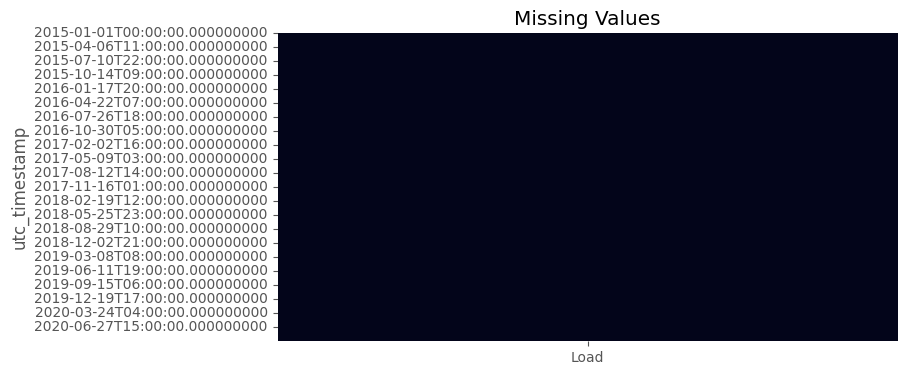

In [11]:
missing = load.isnull().sum()

print(missing)

plt.figure(figsize=(8,4))

sns.heatmap(load.isnull(),cbar=False)

plt.title("Missing Values")

plt.show()

Handle Missing Values

In [12]:
load["Load"] = load["Load"].interpolate(method="time")

load = load.dropna()

print(load.isnull().sum())

Load    0
dtype: int64


Daily Aggregation

In [13]:
daily = load.resample("D").mean()

daily.head()

,Load
utc_timestamp,
2015-01-01 00:00:00+00:00,45346.541667
2015-01-02 00:00:00+00:00,51941.166667
2015-01-03 00:00:00+00:00,46564.750000
2015-01-04 00:00:00+00:00,45082.500000
2015-01-05 00:00:00+00:00,55246.666667


Weekly Aggregation

In [14]:
weekly = load.resample("W").mean()

weekly.head()

,Load
utc_timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


Summary Statistics

In [15]:
print("Hourly")

display(load.describe())

print("Daily")

display(daily.describe())

print("Weekly")

display(weekly.describe())

Hourly


,Load
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


Daily


,Load
count,2100.000000
mean,55492.468552
std,6601.474342
min,38952.666667
25%,50413.447917
50%,56776.916667
75%,60430.093750
max,68183.583333


Weekly


,Load
count,301.000000
mean,55484.350477
std,3762.742475
min,46505.309524
25%,52845.267857
50%,54858.434524
75%,58688.470238
max,63587.011905


Hourly Electricity Plot

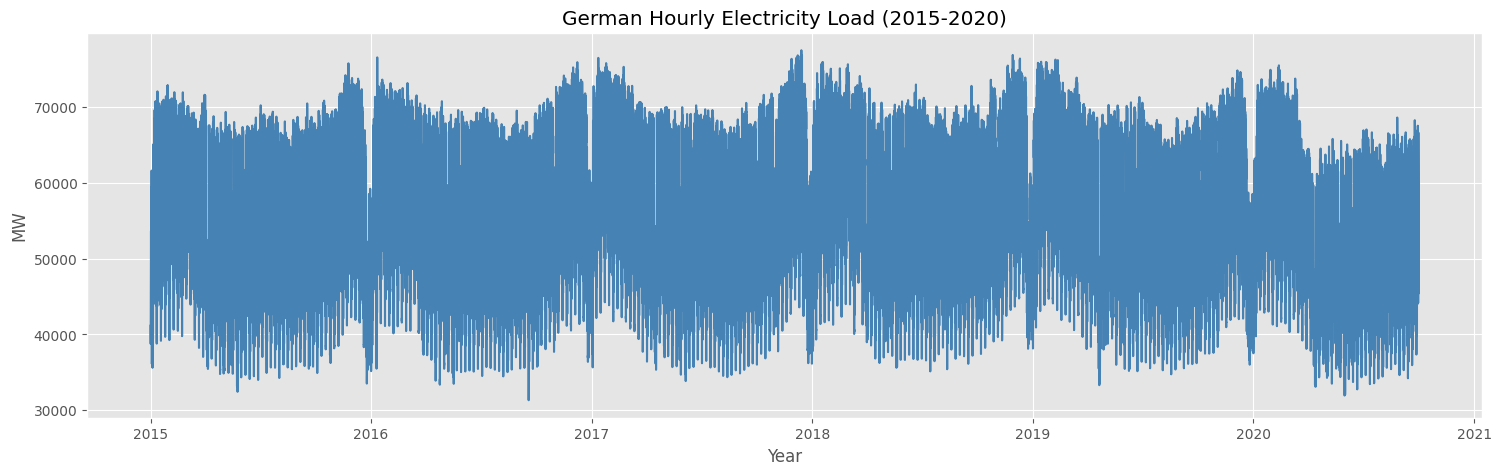

In [16]:
plt.figure(figsize=(18,5))

plt.plot(load,color="steelblue")

plt.title("German Hourly Electricity Load (2015-2020)")

plt.xlabel("Year")

plt.ylabel("MW")

plt.show()

Daily Electricity Plot

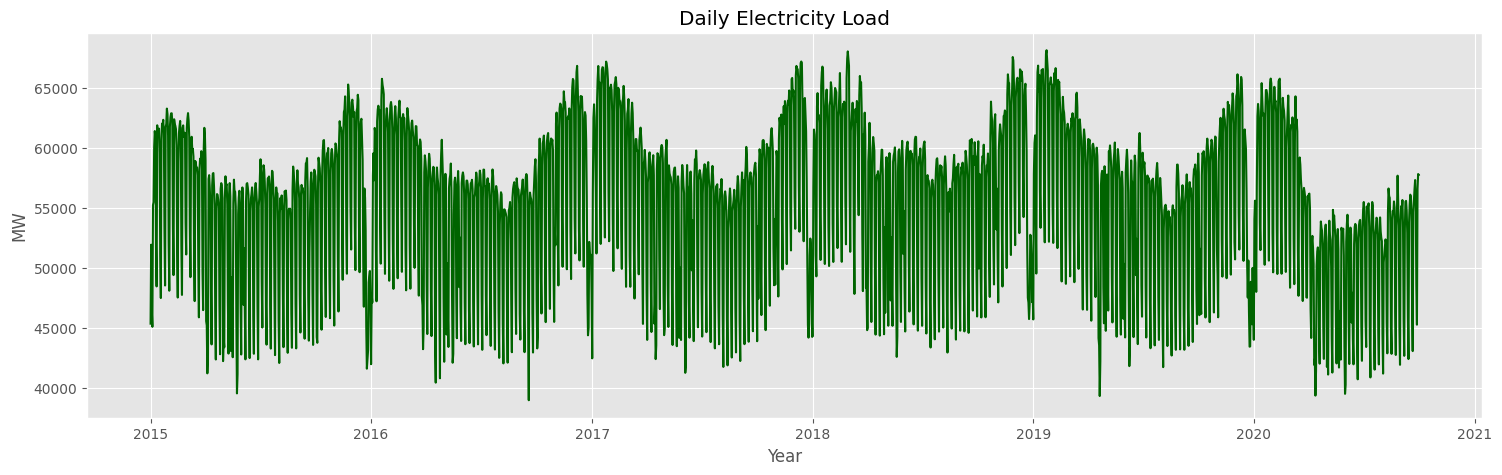

In [17]:
plt.figure(figsize=(18,5))

plt.plot(daily,color="darkgreen")

plt.title("Daily Electricity Load")

plt.xlabel("Year")

plt.ylabel("MW")

plt.show()

Weekly Electricity Plot

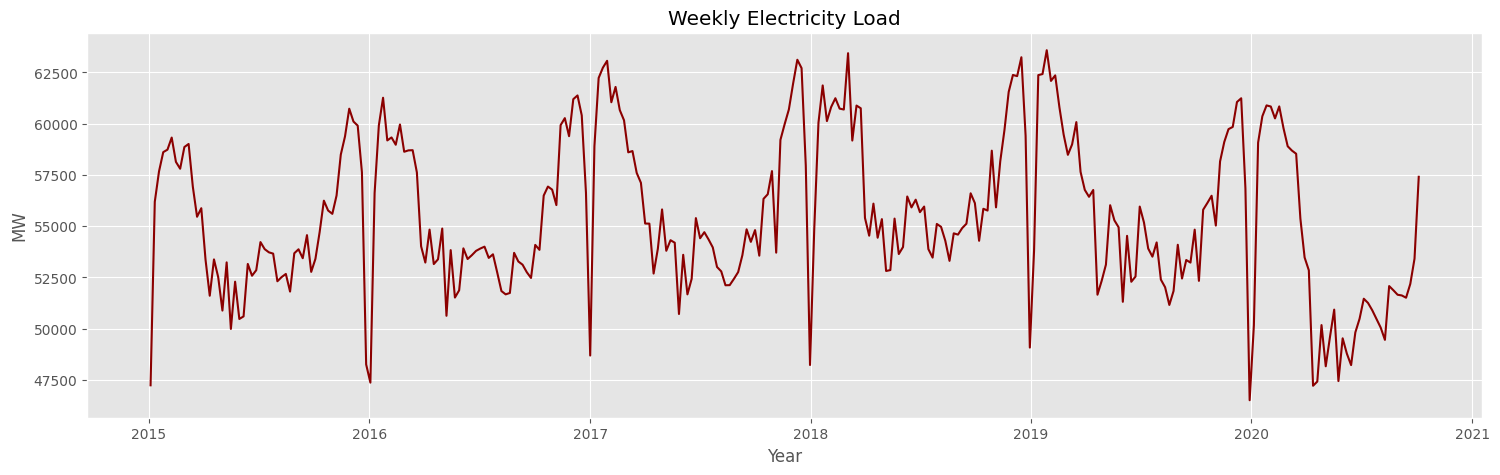

In [18]:
plt.figure(figsize=(18,5))

plt.plot(weekly,color="darkred")

plt.title("Weekly Electricity Load")

plt.xlabel("Year")

plt.ylabel("MW")

plt.show()

Boxplots for EDA

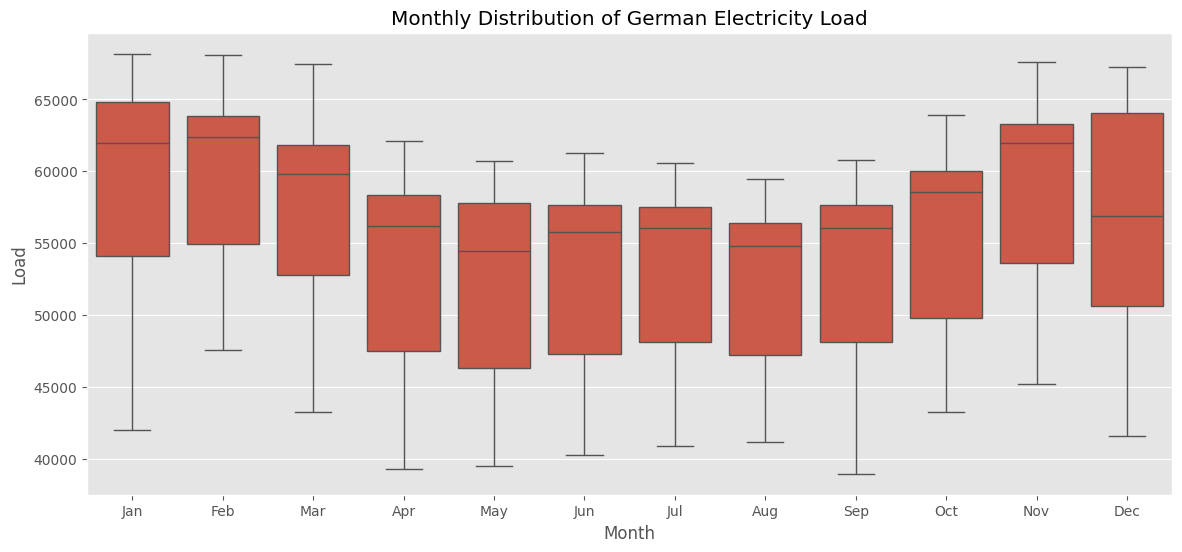

In [19]:
eda = daily.copy()

eda["Month"] = eda.index.month

month_names = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",
    5:"May",6:"Jun",7:"Jul",8:"Aug",
    9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

eda["Month"] = eda["Month"].map(month_names)

plt.figure(figsize=(14,6))

sns.boxplot(x="Month",y="Load",data=eda)

plt.title("Monthly Distribution of German Electricity Load")

plt.show()

### Part 2: Benchmark Models

Seasonal Decomposition

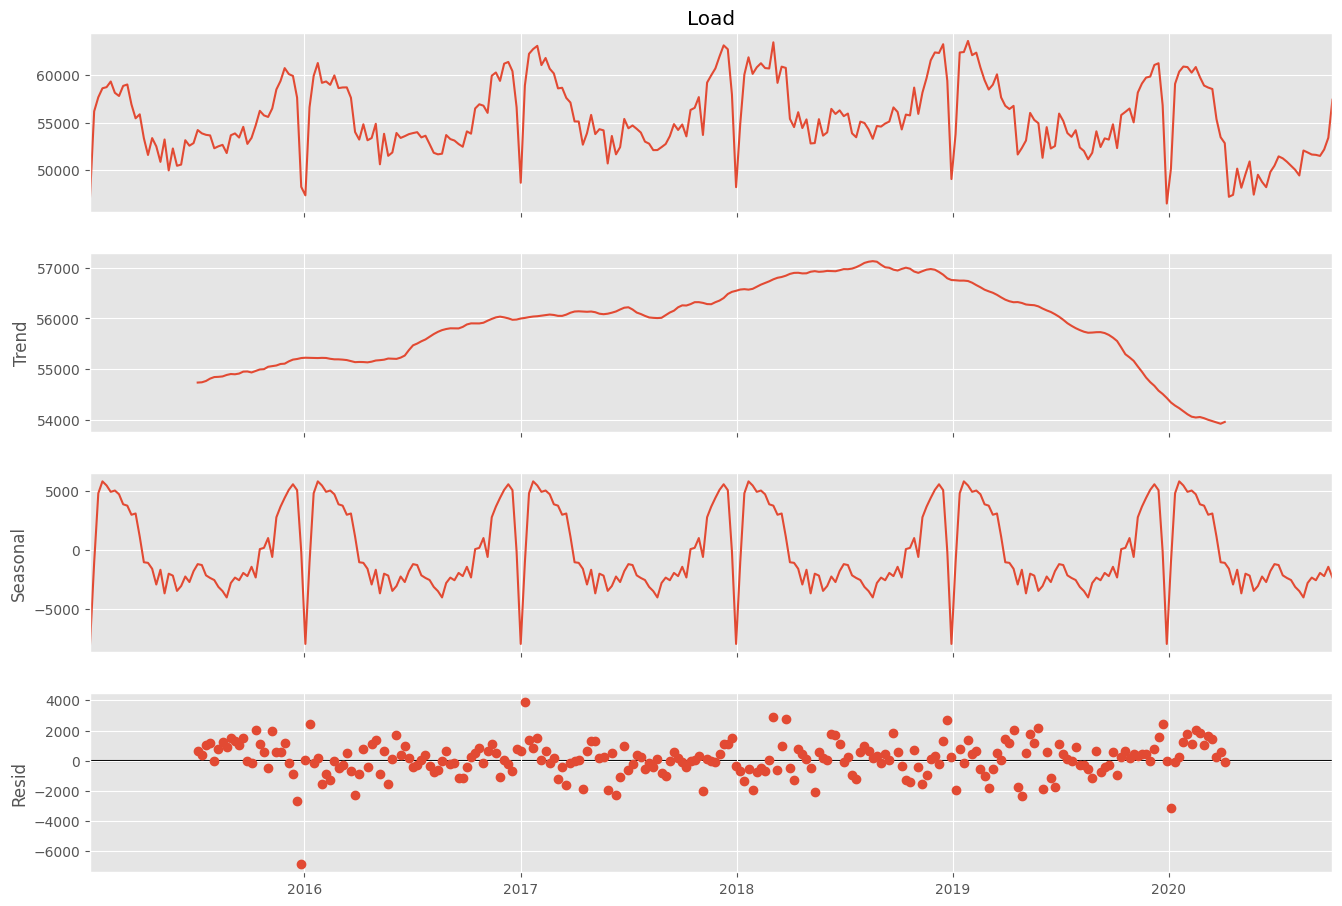

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    weekly['Load'],
    model='additive',
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.show()

Rolling Mean & Standard Deviation

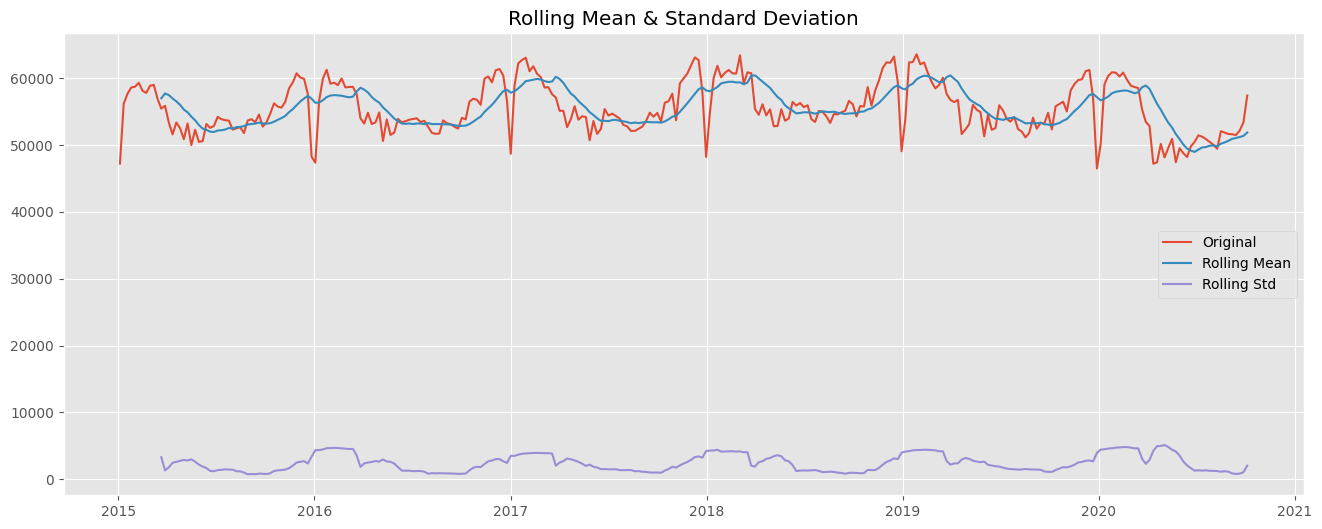

In [21]:
rolling_mean = weekly['Load'].rolling(window=12).mean()
rolling_std = weekly['Load'].rolling(window=12).std()

plt.figure(figsize=(16,6))

plt.plot(weekly['Load'],label='Original')
plt.plot(rolling_mean,label='Rolling Mean')
plt.plot(rolling_std,label='Rolling Std')

plt.title("Rolling Mean & Standard Deviation")

plt.legend()

plt.show()

Augmented Dickey-Fuller Test

In [22]:
adf_result = adfuller(weekly['Load'])

print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])

print("\nCritical Values")

for key,value in adf_result[4].items():
    print(key,":",value)

ADF Statistic : -4.0474718556784826
P-value : 0.0011813497340154512

Critical Values
1% : -3.4529449243622383
5% : -2.871489553425686
10% : -2.572071437887033


KPSS Test

In [23]:
kpss_result = kpss(weekly['Load'])

print("KPSS Statistic :",kpss_result[0])

print("P-value :",kpss_result[1])

print("\nCritical Values")

for key,value in kpss_result[3].items():
    print(key,":",value)

KPSS Statistic : 0.16037407809773105
P-value : 0.1

Critical Values
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


First Difference

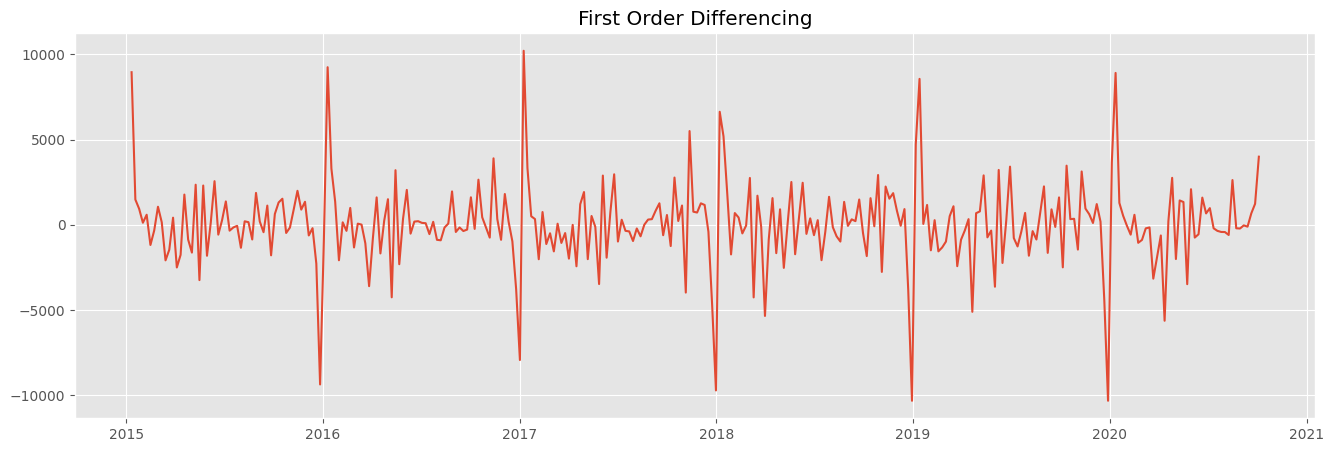

In [24]:
weekly_diff = weekly.diff().dropna()

plt.figure(figsize=(16,5))

plt.plot(weekly_diff)

plt.title("First Order Differencing")

plt.show()

Seasonal Difference (52 Weeks)

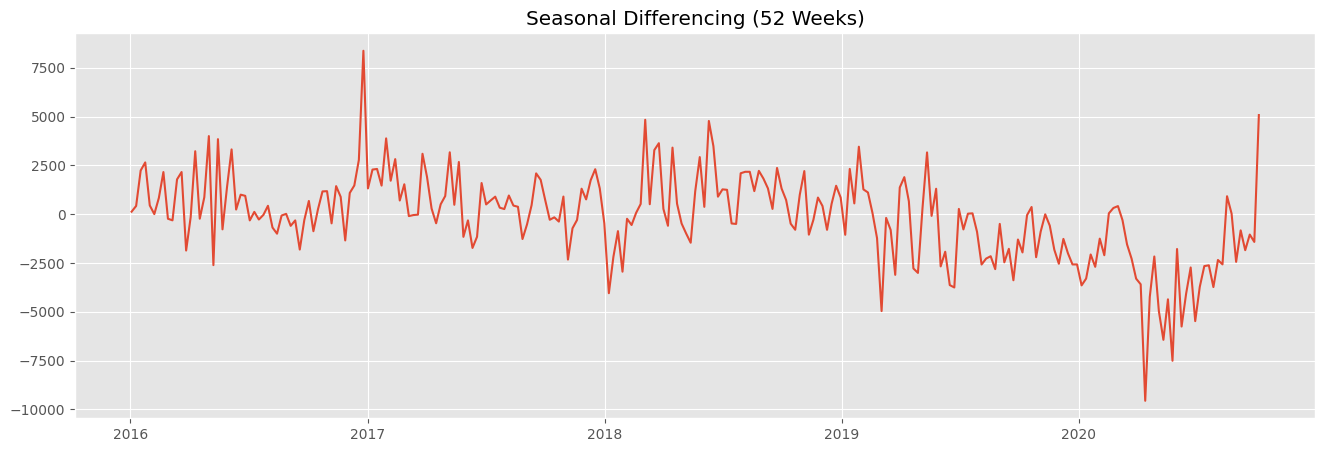

In [25]:
seasonal_diff = weekly.diff(52).dropna()

plt.figure(figsize=(16,5))

plt.plot(seasonal_diff)

plt.title("Seasonal Differencing (52 Weeks)")

plt.show()

ADF Test After Differencing

In [26]:
result = adfuller(weekly_diff['Load'])

print("ADF Statistic :",result[0])

print("P-value :",result[1])

for key,value in result[4].items():

    print(key,value)

ADF Statistic : -7.069318170017982
P-value : 4.984737279649353e-10
1% -3.4529449243622383
5% -2.871489553425686
10% -2.572071437887033


ACF Plot

<Figure size 1200x500 with 0 Axes>

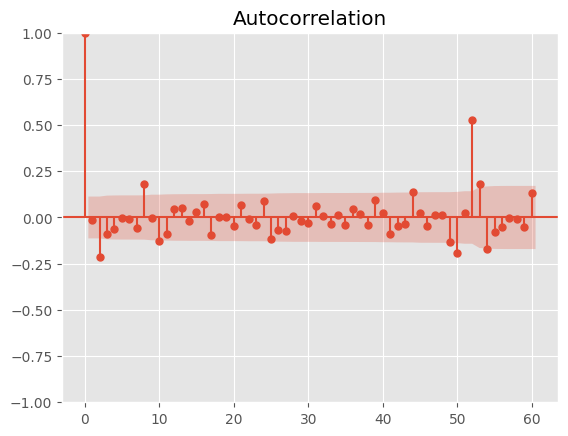

In [27]:
plt.figure(figsize=(12,5))

plot_acf(
    weekly_diff['Load'],
    lags=60
)

plt.show()

PACF Plot

<Figure size 1200x500 with 0 Axes>

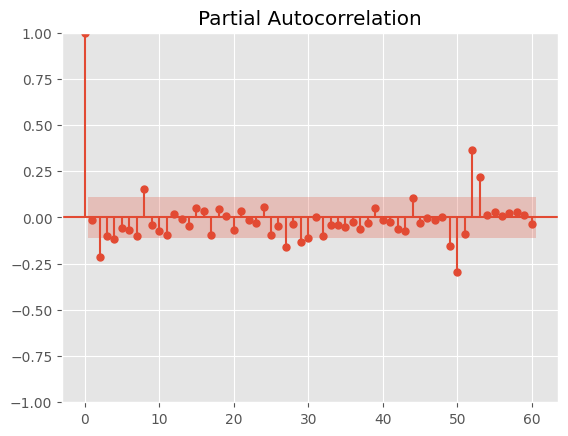

In [28]:
plt.figure(figsize=(12,5))

plot_pacf(
    weekly_diff['Load'],
    lags=60,
    method='ywm'
)

plt.show()

Train/Test Split

In [29]:
forecast_horizon = 104

train = weekly.iloc[:-forecast_horizon]

test = weekly.iloc[-forecast_horizon:]

print(train.shape)

print(test.shape)

(197, 1)
(104, 1)


Mean Forecast

In [30]:
mean_forecast = np.repeat(
    train['Load'].mean(),
    len(test)
)

Naive Forecast

In [31]:
naive_forecast = np.repeat(
    train.iloc[-1]['Load'],
    len(test)
)

Seasonal Naive Forecast

In [32]:
season = 52

seasonal_naive = []

for i in range(len(test)):

    seasonal_naive.append(
        train.iloc[-season+i%season]['Load']
    )

seasonal_naive = np.array(seasonal_naive)

Drift Forecast

In [33]:
drift_forecast = []

for h in range(1,len(test)+1):

    forecast = (
        train.iloc[-1]['Load']
        +
        h*
        (
            train.iloc[-1]['Load']
            -
            train.iloc[0]['Load']
        )
        /
        (len(train)-1)
    )

    drift_forecast.append(forecast)

drift_forecast = np.array(drift_forecast)

Evaluate Benchmark Models

In [34]:
from sklearn.metrics import mean_absolute_percentage_error

benchmark_results = pd.DataFrame(columns=[
    'Model',
    'MAE',
    'RMSE',
    'MAPE',
    'R2'
])

def evaluate(actual,pred,name):

    mae = mean_absolute_error(actual,pred)

    rmse = np.sqrt(
        mean_squared_error(actual,pred)
    )

    mape = mean_absolute_percentage_error(
        actual,
        pred
    )

    r2 = r2_score(actual,pred)

    return [name,mae,rmse,mape,r2]

benchmark_results.loc[len(benchmark_results)] = evaluate(
    test['Load'],
    mean_forecast,
    "Mean"
)

benchmark_results.loc[len(benchmark_results)] = evaluate(
    test['Load'],
    naive_forecast,
    "Naive"
)

benchmark_results.loc[len(benchmark_results)] = evaluate(
    test['Load'],
    seasonal_naive,
    "Seasonal Naive"
)

benchmark_results.loc[len(benchmark_results)] = evaluate(
    test['Load'],
    drift_forecast,
    "Drift"
)

benchmark_results

,Model,MAE,RMSE,MAPE,R2
0,Mean,3788.833122,4397.299694,0.069692,-0.012110
1,Naive,3783.202934,4459.108546,0.067901,-0.040763
2,Seasonal Naive,2318.520585,3006.760812,0.044089,0.526790
3,Drift,4339.890674,5117.957264,0.080497,-0.371037


### Part 3: SARIMA

Import Additional Libraries

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

print("SARIMA libraries imported successfully.")

SARIMA libraries imported successfully.


Define Parameter Grid

In [36]:
p = range(0,7)
d = range(0,3)
q = range(0,7)

pdq = list(itertools.product(p,d,q))

print("Total parameter combinations:", len(pdq))

Total parameter combinations: 147


SARIMA Grid Search Using AIC

In [37]:
results = []

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:

    try:

        model = SARIMAX(
            train['Load'],
            order=order,
            seasonal_order=(1,1,1,52),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        results.append({
            "Order": order,
            "AIC": fitted.aic
        })

        if fitted.aic < best_aic:

            best_aic = fitted.aic
            best_order = order
            best_model = fitted

    except:

        continue

print("Grid Search Finished")

Grid Search Finished


AIC Comparison Table

In [38]:
aic_table = pd.DataFrame(results)

aic_table = aic_table.sort_values(
    by="AIC"
)

aic_table.head(10)

,Order,AIC
62,"(2, 2, 6)",1482.265710
41,"(1, 2, 6)",1482.981189
83,"(3, 2, 6)",1483.723601
104,"(4, 2, 6)",1485.042910
20,"(0, 2, 6)",1486.105768
125,"(5, 2, 6)",1487.217108
145,"(6, 2, 6)",1488.111498
13,"(0, 1, 6)",1490.461384
34,"(1, 1, 6)",1491.630998
55,"(2, 1, 6)",1493.576468


Best Model

In [39]:
print("Best Order :", best_order)

print("Best AIC :", best_aic)

Best Order : (2, 2, 6)
Best AIC : 1482.2657095725963


Fit Final SARIMA Model

In [40]:
sarima = SARIMAX(

    train["Load"],

    order=best_order,

    seasonal_order=(1,1,1,52),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 Load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -730.133
Date:                              Thu, 16 Jul 2026   AIC                           1482.266
Time:                                      14:18:17   BIC                           1509.005
Sample:                                  01-04-2015   HQIC                          1493.015
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8910      0.292     -3.047      0.002      -1.464      -0.318
ar.L2         -0.74

Actual vs Fitted Values

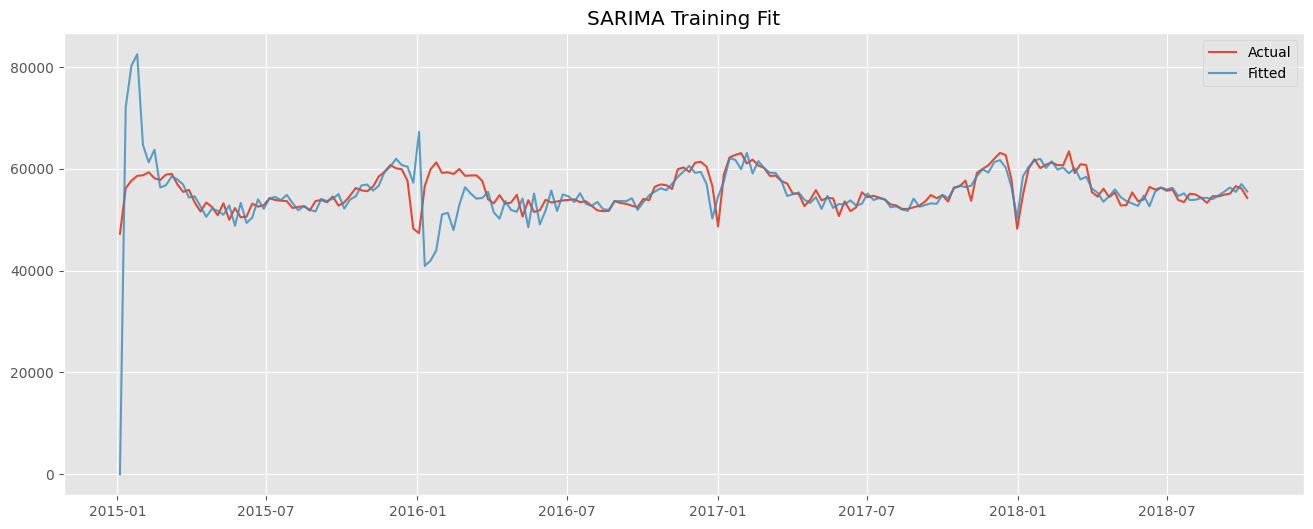

In [41]:
plt.figure(figsize=(16,6))

plt.plot(
    train.index,
    train['Load'],
    label="Actual"
)

plt.plot(
    train.index,
    sarima_fit.fittedvalues,
    label="Fitted",
    alpha=0.8
)

plt.title("SARIMA Training Fit")

plt.legend()

plt.show()

Save Model Residuals

In [42]:
residuals = sarima_fit.resid

print(residuals.describe())

count      197.000000
mean       409.477486
std       5452.335163
min     -23884.465542
25%       -891.348013
50%        128.555230
75%       1467.722524
max      47233.739583
dtype: float64


Residual Time Series Plot

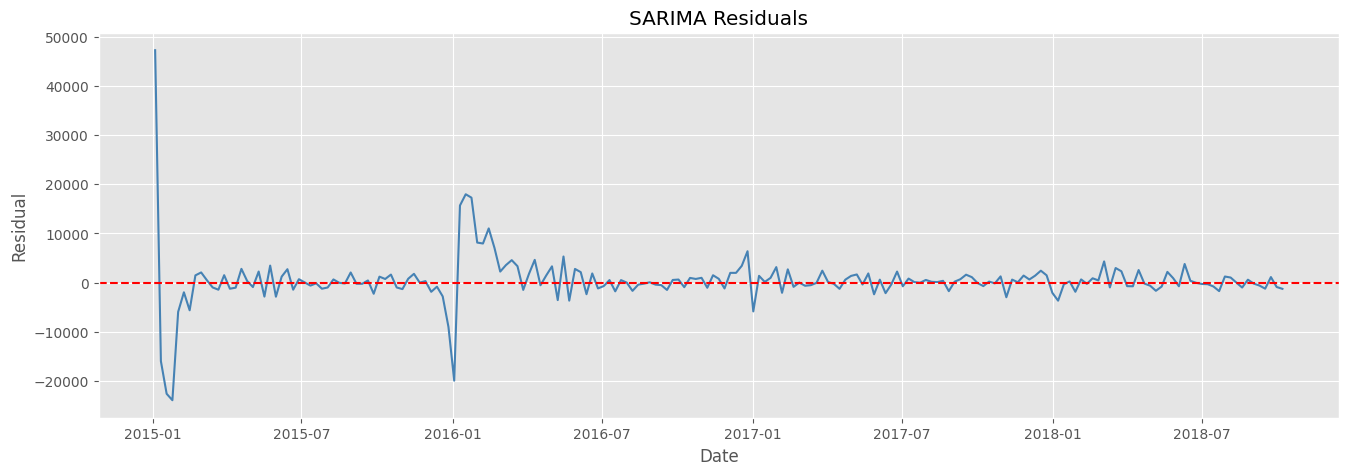

In [43]:
plt.figure(figsize=(16,5))

plt.plot(residuals, color='steelblue')

plt.axhline(y=0, color='red', linestyle='--')

plt.title("SARIMA Residuals")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.show()

Residual Distribution & Q-Q Plot

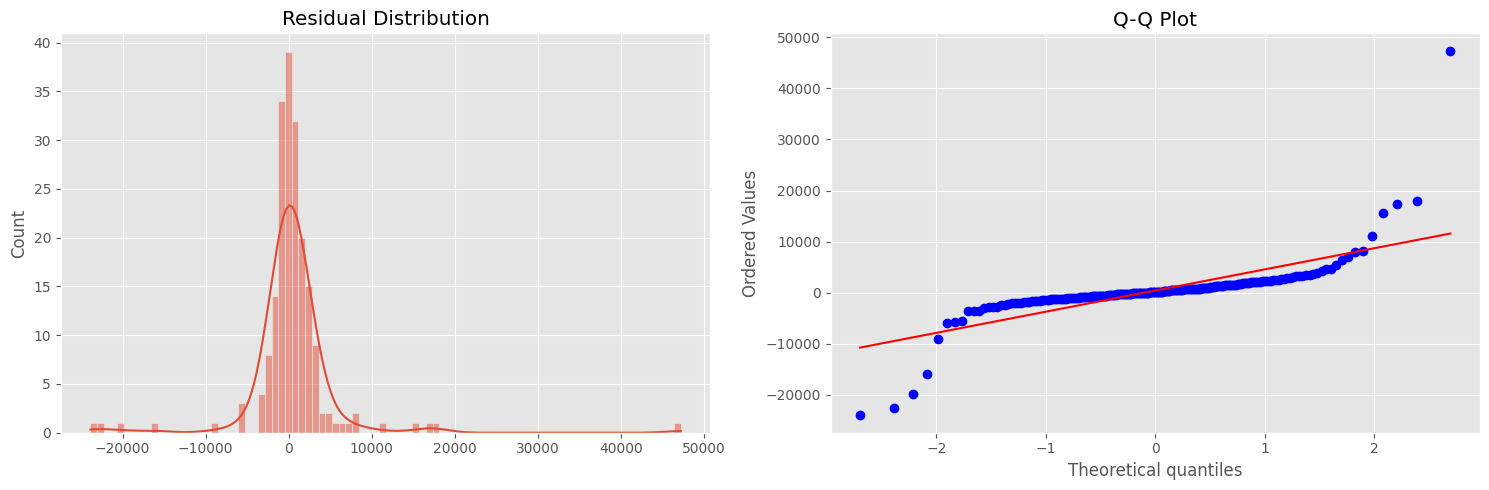

In [44]:
from scipy.stats import probplot

fig, ax = plt.subplots(1,2, figsize=(15,5))

# Histogram
sns.histplot(residuals, kde=True, ax=ax[0])

ax[0].set_title("Residual Distribution")

# QQ Plot
probplot(residuals, dist="norm", plot=ax[1])

ax[1].set_title("Q-Q Plot")

plt.tight_layout()

plt.show()

Residual ACF Plot

<Figure size 1200x500 with 0 Axes>

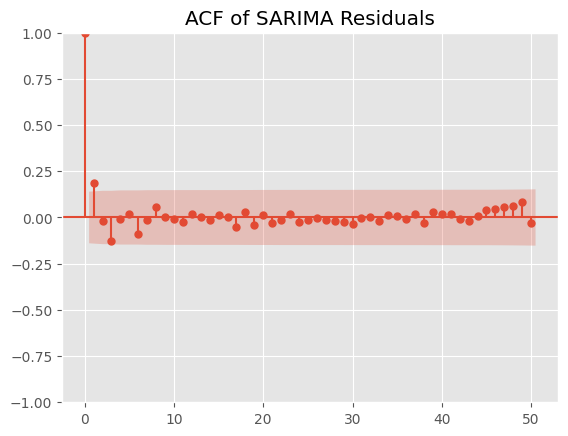

In [45]:
plt.figure(figsize=(12,5))

plot_acf(
    residuals.dropna(),
    lags=50
)

plt.title("ACF of SARIMA Residuals")

plt.show()

Ljung–Box Test

In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(
    residuals.dropna(),
    lags=[10,20],
    return_df=True
)

ljung

,lb_stat,lb_pvalue
10,12.631492,0.245011
20,14.040640,0.828429


Forecast the Last 2 Years

In [47]:
forecast = sarima_fit.get_forecast(
    steps=len(test)
)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

forecast_mean.head()

,predicted_mean
2018-10-14 00:00:00+00:00,58164.065658
2018-10-21 00:00:00+00:00,58701.654253
2018-10-28 00:00:00+00:00,59496.218471
2018-11-04 00:00:00+00:00,56749.889164
2018-11-11 00:00:00+00:00,61880.630129


Forecast Plot with 95% Confidence Interval:

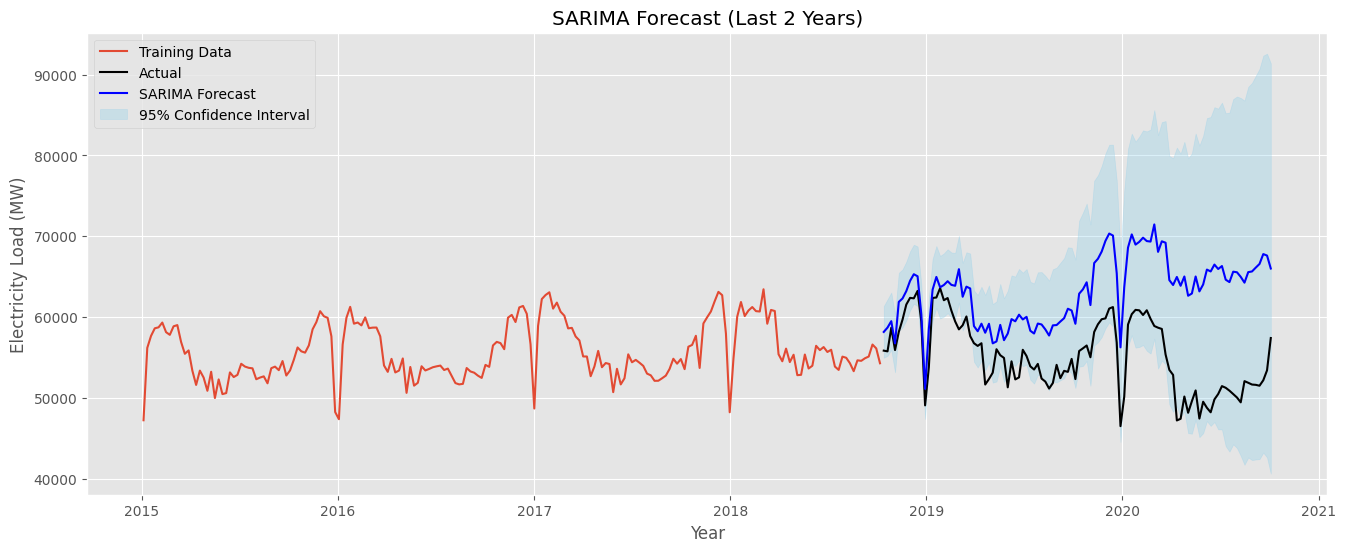

In [48]:
plt.figure(figsize=(16,6))

plt.plot(
    train.index,
    train["Load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Load"],
    label="Actual",
    color="black"
)

plt.plot(
    test.index,
    forecast_mean,
    label="SARIMA Forecast",
    color="blue"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="skyblue",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (Last 2 Years)")

plt.xlabel("Year")

plt.ylabel("Electricity Load (MW)")

plt.legend()

plt.show()

SARIMA Performance Evaluation

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

sarima_mae = mean_absolute_error(
    test["Load"],
    forecast_mean
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Load"],
        forecast_mean
    )
)

sarima_mape = mean_absolute_percentage_error(
    test["Load"],
    forecast_mean
)

sarima_r2 = r2_score(
    test["Load"],
    forecast_mean
)

sarima_results = pd.DataFrame({
    "Model":["SARIMA"],
    "MAE":[sarima_mae],
    "RMSE":[sarima_rmse],
    "MAPE":[sarima_mape],
    "R2":[sarima_r2]
})

display(sarima_results)

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,8077.824189,9434.251167,0.151863,-3.658763


### Part 4: SARIMAX

Install Additional Packages

In [50]:
!pip install -q openmeteo-requests requests-cache retry-requests holidays

Import Required Libraries

In [51]:
import requests
import holidays

print("Libraries Imported Successfully")

Libraries Imported Successfully


Download Berlin Temperature *Data*

In [52]:
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52"
    "&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-10-31"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

response = requests.get(url)

weather = response.json()

Convert Temperature to DataFrame

In [53]:
temperature = pd.DataFrame({
    "Date": pd.to_datetime(
        weather["daily"]["time"],
        utc=True
    ),
    "Temperature": weather["daily"]["temperature_2m_mean"]
})

# Remove timezone information
temperature["Date"] = temperature["Date"].dt.tz_localize(None)

temperature.set_index("Date", inplace=True)

temperature.head()

,Temperature
Date,
2015-01-01,2.6
2015-01-02,4.9
2015-01-03,3.8
2015-01-04,2.8
2015-01-05,2.9


Convert Daily Temperature to Weekly

In [54]:
weekly_temp = temperature.resample("W").mean()

weekly_temp.head()

,Temperature
Date,
2015-01-04,3.525000
2015-01-11,3.914286
2015-01-18,4.842857
2015-01-25,0.057143
2015-02-01,1.400000


Create German Holiday Feature

In [55]:
import holidays

de_holidays = holidays.Germany()

temperature["Holiday"] = temperature.index.map(
    lambda x: 1 if x.date() in de_holidays else 0
)

weekly_holiday = temperature[["Holiday"]].resample("W").sum()

weekly_holiday.head()

,Holiday
Date,
2015-01-04,1
2015-01-11,0
2015-01-18,0
2015-01-25,0
2015-02-01,0


Merge Electricity, Temperature and Holidays

In [56]:
# Make copies
sarimax_data = weekly.copy()

# Remove timezone if present
sarimax_data.index = sarimax_data.index.tz_localize(None)

weekly_temp.index = weekly_temp.index.tz_localize(None)

weekly_holiday.index = weekly_holiday.index.tz_localize(None)

# Merge
sarimax_data = sarimax_data.join(weekly_temp)

sarimax_data = sarimax_data.join(weekly_holiday)

sarimax_data.head()

,Load,Temperature,Holiday
utc_timestamp,,,
2015-01-04,47233.739583,3.525000,1
2015-01-11,56191.101190,3.914286,0
2015-01-18,57672.678571,4.842857,0
2015-01-25,58613.303571,0.057143,0
2015-02-01,58734.029762,1.400000,0


Handle Missing Values

In [57]:
sarimax_data = sarimax_data.interpolate()

sarimax_data.dropna(inplace=True)

sarimax_data.isnull().sum()

,0
Load,0
Temperature,0
Holiday,0


Train/Test Split

In [58]:
train_exog = sarimax_data.iloc[:-104]

test_exog = sarimax_data.iloc[-104:]

X_train = train_exog[
    ["Temperature","Holiday"]
]

X_test = test_exog[
    ["Temperature","Holiday"]
]

y_train = train_exog["Load"]

y_test = test_exog["Load"]

Fit SARIMAX Model

In [59]:
sarimax = SARIMAX(

    y_train,

    exog=X_train,

    order=best_order,

    seasonal_order=(1,1,1,52),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarimax_fit = sarimax.fit()

print(sarimax_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 Load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -709.206
Date:                              Thu, 16 Jul 2026   AIC                           1444.413
Time:                                      14:20:05   BIC                           1476.013
Sample:                                  01-04-2015   HQIC                          1457.116
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Temperature  -100.1308     49.251     -2.033      0.042    -196.661      -3.601
Holiday     -189

Forecast Using Temperature and Holiday

In [60]:
forecast = sarimax_fit.get_forecast(

    steps=len(test_exog),

    exog=X_test

)

sarimax_forecast = forecast.predicted_mean

sarimax_ci = forecast.conf_int()

Forecast Plot

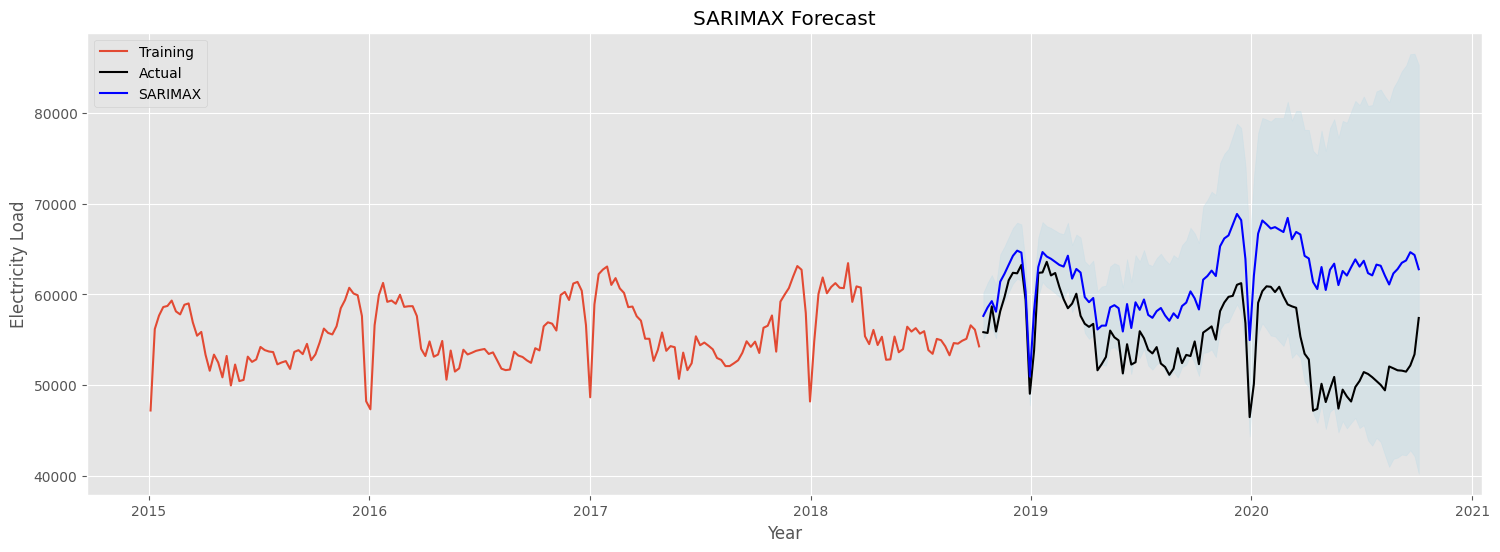

In [61]:
plt.figure(figsize=(18,6))

plt.plot(

    train_exog.index,

    y_train,

    label="Training"

)

plt.plot(

    test_exog.index,

    y_test,

    label="Actual",

    color="black"

)

plt.plot(

    test_exog.index,

    sarimax_forecast,

    label="SARIMAX",

    color="blue"

)

plt.fill_between(

    sarimax_ci.index,

    sarimax_ci.iloc[:,0],

    sarimax_ci.iloc[:,1],

    alpha=0.25,

    color="lightblue"

)

plt.title("SARIMAX Forecast")

plt.xlabel("Year")

plt.ylabel("Electricity Load")

plt.legend()

plt.show()

Evaluate SARIMAX

In [62]:
sarimax_mae = mean_absolute_error(

    y_test,

    sarimax_forecast

)

sarimax_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        sarimax_forecast

    )

)

sarimax_mape = mean_absolute_percentage_error(

    y_test,

    sarimax_forecast

)

sarimax_r2 = r2_score(

    y_test,

    sarimax_forecast

)

sarimax_results = pd.DataFrame({

    "Model":["SARIMAX"],

    "MAE":[sarimax_mae],

    "RMSE":[sarimax_rmse],

    "MAPE":[sarimax_mape],

    "R2":[sarimax_r2]

})

display(sarimax_results)

,Model,MAE,RMSE,MAPE,R2
0,SARIMAX,6738.312701,7825.285916,0.126782,-2.205208


### Part 5: Machine Learning

Create Time-Series Features

In [63]:
ml_data = sarimax_data.copy()

# Lag Features
ml_data["lag_1"] = ml_data["Load"].shift(1)
ml_data["lag_2"] = ml_data["Load"].shift(2)
ml_data["lag_4"] = ml_data["Load"].shift(4)
ml_data["lag_12"] = ml_data["Load"].shift(12)
ml_data["lag_52"] = ml_data["Load"].shift(52)

# Rolling Statistics
ml_data["rolling_mean_4"] = ml_data["Load"].rolling(4).mean()
ml_data["rolling_std_4"] = ml_data["Load"].rolling(4).std()

ml_data["rolling_mean_12"] = ml_data["Load"].rolling(12).mean()
ml_data["rolling_std_12"] = ml_data["Load"].rolling(12).std()

# Calendar Features
ml_data["Month"] = ml_data.index.month
ml_data["Week"] = ml_data.index.isocalendar().week.astype(int)
ml_data["Quarter"] = ml_data.index.quarter
ml_data["Year"] = ml_data.index.year

ml_data.dropna(inplace=True)

print(ml_data.shape)
ml_data.head()

(249, 16)


,Load,Temperature,Holiday,lag_1,lag_2,lag_4,lag_12,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_12,rolling_std_12,Month,Week,Quarter,Year
utc_timestamp,,,,,,,,,,,,,,,,
2016-01-03,47364.035714,0.514286,1,48253.363095,57627.857143,60106.678571,54714.547619,47233.739583,53288.147321,6405.488671,56330.935020,4354.952831,1,53,1,2016
2016-01-10,56615.142857,-3.228571,0,47364.035714,48253.363095,59907.333333,56243.970238,56191.101190,52465.099702,5404.828139,56361.866071,4355.597091,1,1,1,2016
2016-01-17,59913.910714,0.228571,0,56615.142857,47364.035714,57627.857143,55763.964286,57672.678571,53036.613095,6195.716598,56707.694940,4467.130964,1,2,1,2016
2016-01-24,61267.529762,-3.542857,0,59913.910714,56615.142857,48253.363095,55601.589286,58613.303571,56290.154762,6263.308168,57179.856647,4635.840939,1,3,1,2016
2016-01-31,59185.089286,6.400000,0,61267.529762,59913.910714,47364.035714,56496.375000,58734.029762,59245.418155,1954.294874,57403.916171,4664.689525,1,4,1,2016


Define Features

In [64]:
features = [

    "Temperature",
    "Holiday",

    "lag_1",
    "lag_2",
    "lag_4",
    "lag_12",
    "lag_52",

    "rolling_mean_4",
    "rolling_std_4",

    "rolling_mean_12",
    "rolling_std_12",

    "Month",
    "Week",
    "Quarter",
    "Year"

]

target = "Load"

X = ml_data[features]

y = ml_data[target]

Train/Test Split

In [65]:
train_ml = ml_data.iloc[:-104]

test_ml = ml_data.iloc[-104:]

X_train = train_ml[features]
X_test = test_ml[features]

y_train = train_ml[target]
y_test = test_ml[target]

print(X_train.shape)
print(X_test.shape)

(145, 15)
(104, 15)


Random Forest Hyperparameter Search

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_rf = GridSearchCV(

    rf,

    param_grid,

    cv=3,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


Train Best Random Forest

In [67]:
rf_model = grid_rf.best_estimator_

rf_model.fit(

    X_train,

    y_train

)

rf_pred = rf_model.predict(X_test)

Random Forest Feature Importance

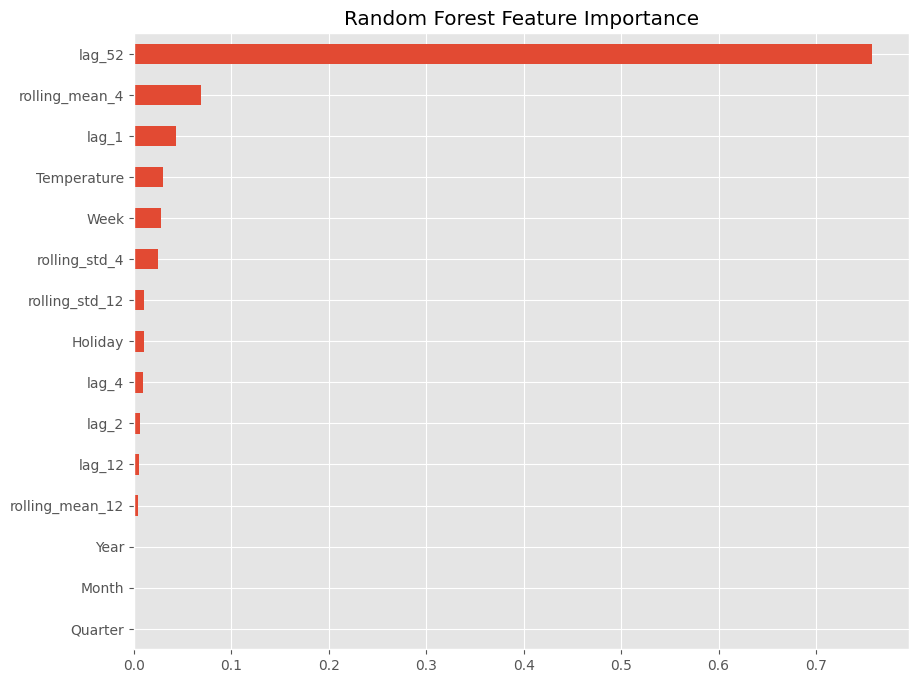

In [68]:
importance = pd.Series(

    rf_model.feature_importances_,

    index=features

)

importance = importance.sort_values()

plt.figure(figsize=(10,8))

importance.plot.barh()

plt.title("Random Forest Feature Importance")

plt.show()

Random Forest Forecast Plot

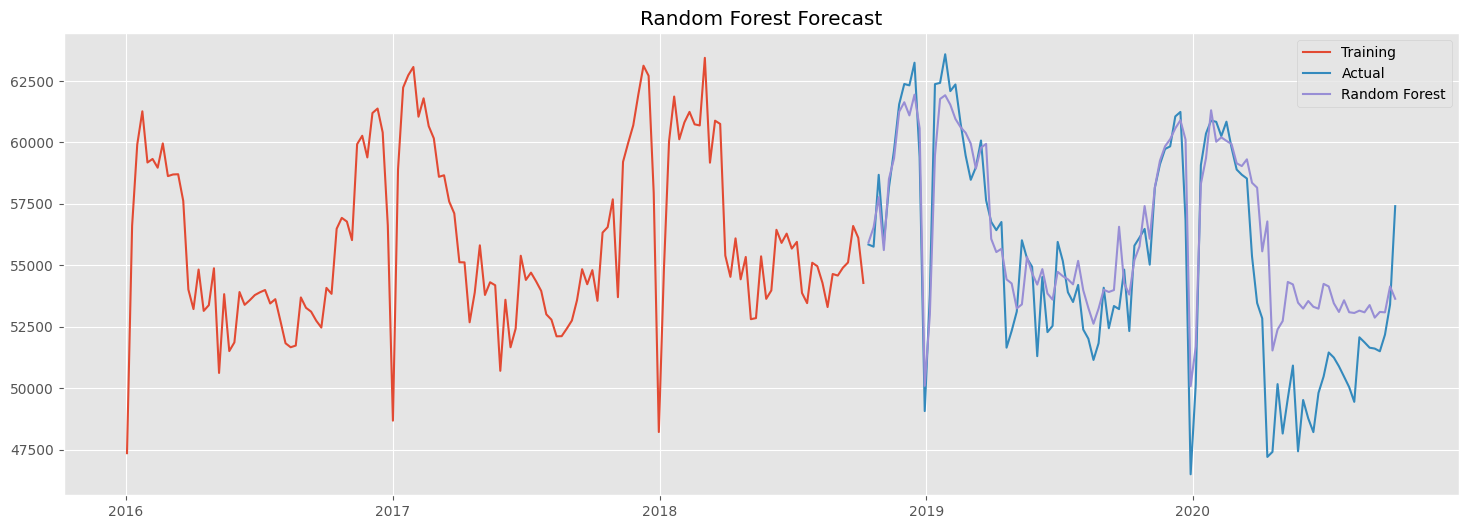

In [69]:
plt.figure(figsize=(18,6))

plt.plot(

    train_ml.index,

    y_train,

    label="Training"

)

plt.plot(

    test_ml.index,

    y_test,

    label="Actual"

)

plt.plot(

    test_ml.index,

    rf_pred,

    label="Random Forest"

)

plt.title("Random Forest Forecast")

plt.legend()

plt.show()

Random Forest Evaluation

In [70]:
rf_mae = mean_absolute_error(

    y_test,

    rf_pred

)

rf_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_pred

    )

)

rf_mape = mean_absolute_percentage_error(

    y_test,

    rf_pred

)

rf_r2 = r2_score(

    y_test,

    rf_pred

)

rf_results = pd.DataFrame({

    "Model":["Random Forest"],

    "MAE":[rf_mae],

    "RMSE":[rf_rmse],

    "MAPE":[rf_mape],

    "R2":[rf_r2]

})

display(rf_results)

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,1619.506679,2258.790701,0.031007,0.732941


Gradient Boosting Regressor

In [71]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

gbr.fit(

    X_train,

    y_train

)

gbr_pred = gbr.predict(X_test)

Gradient Boosting Forecast

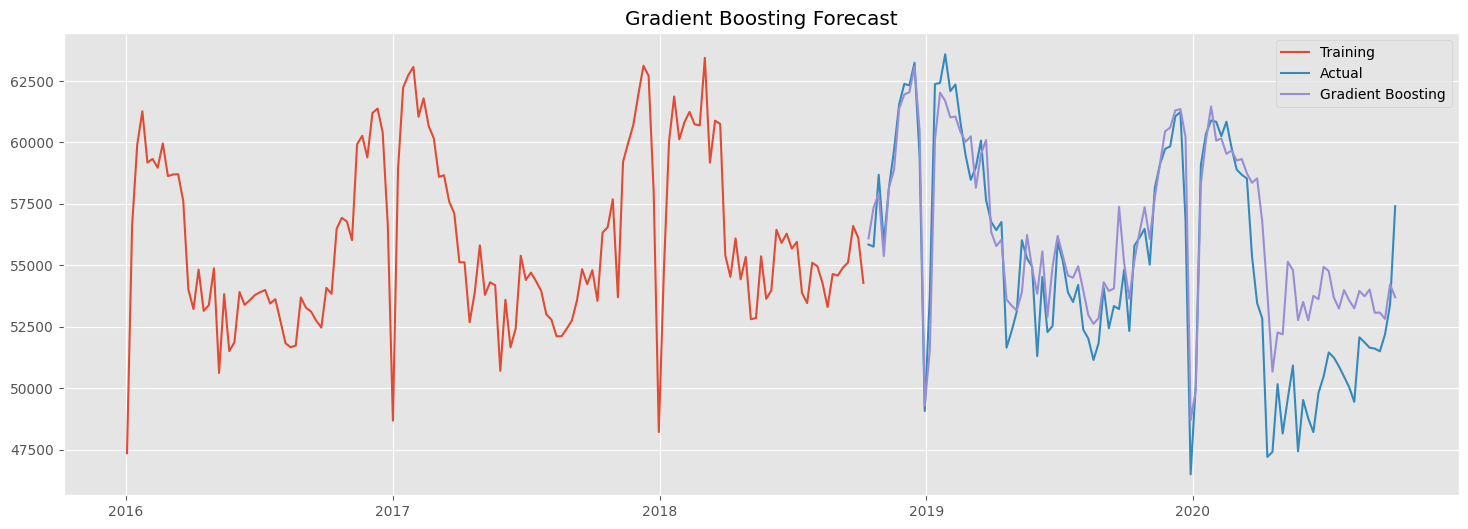

In [72]:
plt.figure(figsize=(18,6))

plt.plot(

    train_ml.index,

    y_train,

    label="Training"

)

plt.plot(

    test_ml.index,

    y_test,

    label="Actual"

)

plt.plot(

    test_ml.index,

    gbr_pred,

    label="Gradient Boosting"

)

plt.legend()

plt.title("Gradient Boosting Forecast")

plt.show()

Gradient Boosting Evaluation

In [73]:
gbr_mae = mean_absolute_error(

    y_test,

    gbr_pred

)

gbr_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        gbr_pred

    )

)

gbr_mape = mean_absolute_percentage_error(

    y_test,

    gbr_pred

)

gbr_r2 = r2_score(

    y_test,

    gbr_pred

)

gbr_results = pd.DataFrame({

    "Model":["Gradient Boosting"],

    "MAE":[gbr_mae],

    "RMSE":[gbr_rmse],

    "MAPE":[gbr_mape],

    "R2":[gbr_r2]

})

display(gbr_results)

,Model,MAE,RMSE,MAPE,R2
0,Gradient Boosting,1600.579387,2200.889899,0.030567,0.746457


Compare Machine Learning Models

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,1619.506679,2258.790701,0.031007,0.732941
1,Gradient Boosting,1600.579387,2200.889899,0.030567,0.746457


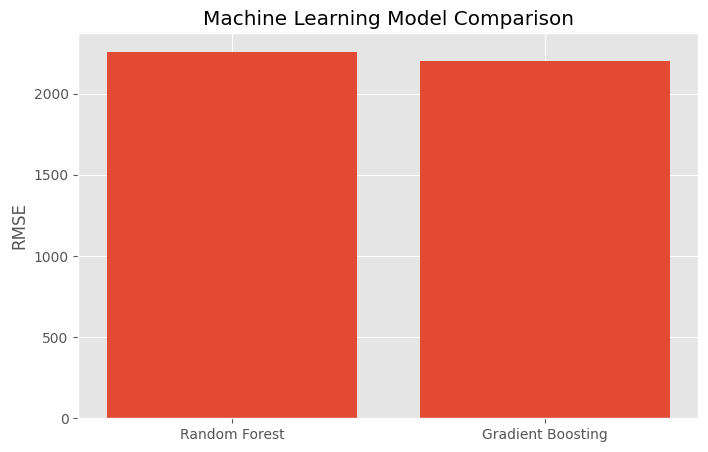

In [74]:
ml_results = pd.concat(

    [

        rf_results,

        gbr_results

    ],

    ignore_index=True

)

display(ml_results)

plt.figure(figsize=(8,5))

plt.bar(

    ml_results["Model"],

    ml_results["RMSE"]

)

plt.ylabel("RMSE")

plt.title("Machine Learning Model Comparison")

plt.show()

### Part 6: LSTM

Prepare Hourly Dataset

In [75]:
hourly = load.copy()

print(hourly.shape)

hourly.head()

(50400, 1)


,Load
utc_timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


Train/Test Split (Hourly)

In [76]:
forecast_hours = 24 * 365 * 2

train_hourly = hourly.iloc[:-forecast_hours]

test_hourly = hourly.iloc[-forecast_hours:]

print(train_hourly.shape)

print(test_hourly.shape)

(32880, 1)
(17520, 1)


Scale Data

In [77]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_hourly)

test_scaled = scaler.transform(test_hourly)

Create Sequences

In [78]:
LOOK_BACK = 24

def create_sequences(data, look_back):

    X = []
    y = []

    for i in range(look_back, len(data)):

        X.append(data[i-look_back:i,0])

        y.append(data[i,0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_scaled,
    LOOK_BACK
)

combined = np.concatenate(
    [train_scaled[-LOOK_BACK:], test_scaled]
)

X_test, y_test = create_sequences(
    combined,
    LOOK_BACK
)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(32856, 24, 1)
(17520, 24, 1)


Build LSTM Model

In [79]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(

    LSTM(
        128,
        return_sequences=True,
        input_shape=(LOOK_BACK,1)
    )

)

model.add(Dropout(0.3))

model.add(

    LSTM(
        64
    )

)

model.add(Dropout(0.3))

model.add(Dense(32,activation="relu"))

model.add(Dense(1))

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [80]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=128,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 32s 136ms/step - loss: 0.0284 - mae: 0.1280 - val_loss: 0.0077 - val_mae: 0.0690
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 28s 134ms/step - loss: 0.0084 - mae: 0.0711 - val_loss: 0.0035 - val_mae: 0.0430
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 132ms/step - loss: 0.0049 - mae: 0.0541 - val_loss: 0.0023 - val_mae: 0.0369
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - loss: 0.0034 - mae: 0.0453 - val_loss: 0.0017 - val_mae: 0.0319
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - loss: 0.0027 - mae: 0.0407 - val_loss: 0.0013 - val_mae: 0.0272
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - loss: 0.0022 - mae: 0.0367 - val_loss: 0.0010 - val_mae: 0.0243
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - loss: 0.0019 - mae: 0.0340 - val_loss: 0.0011 - val_mae: 0.0247
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - loss: 0.0016 - mae: 0.0312 - val_loss: 9.4784e-04 - val_mae: 0.0236
Epoch 9/30
206/206 ━━━━━━━━━

Training History

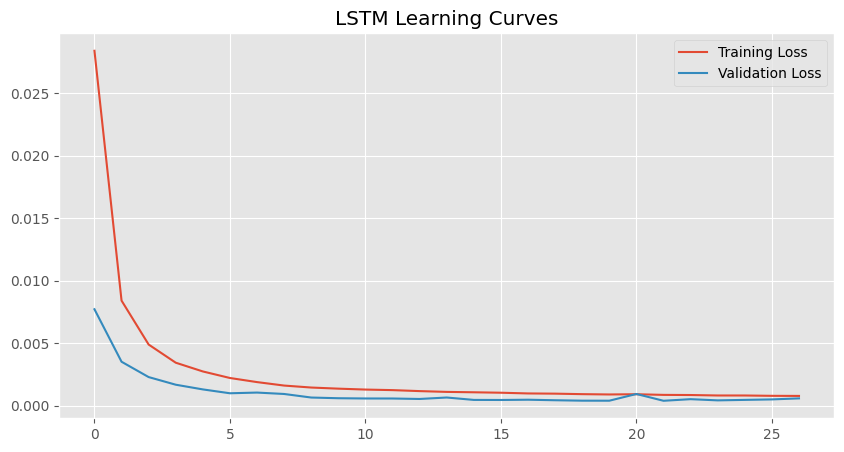

In [81]:
plt.figure(figsize=(10,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.legend()

plt.title("LSTM Learning Curves")

plt.show()

Predict

In [82]:
pred_scaled = model.predict(X_test)

pred = scaler.inverse_transform(pred_scaled)

actual = scaler.inverse_transform(

    y_test.reshape(-1,1)

)

548/548 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


Forecast Plot

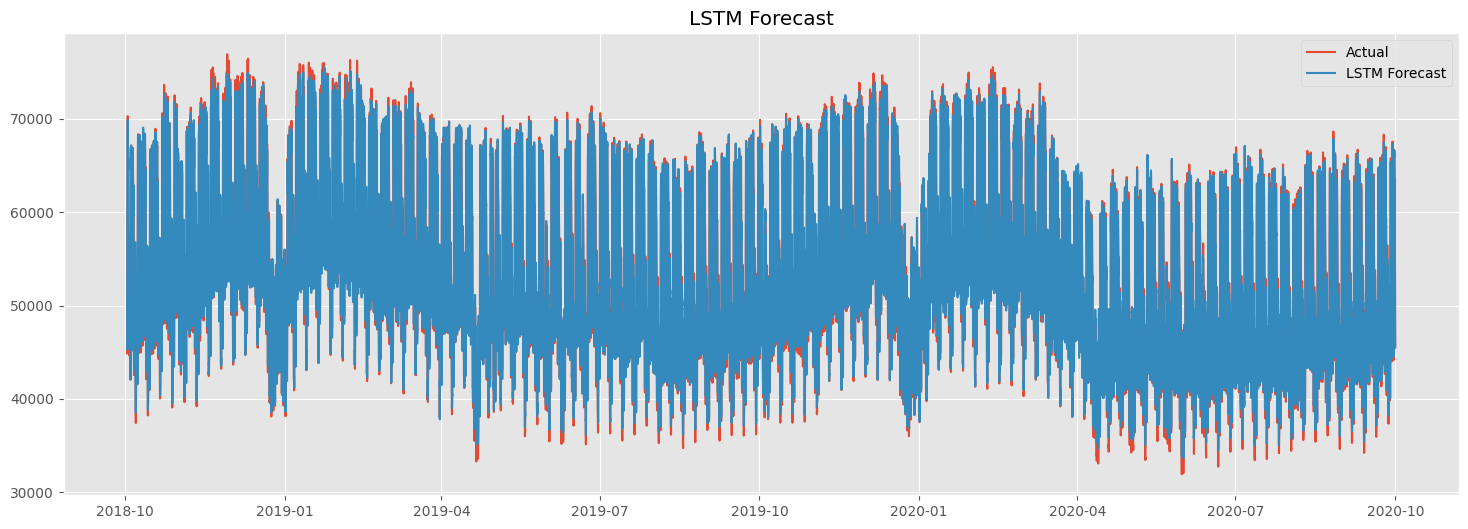

In [83]:
plt.figure(figsize=(18,6))

plt.plot(

    test_hourly.index,

    actual,

    label="Actual"

)

plt.plot(

    test_hourly.index,

    pred,

    label="LSTM Forecast"

)

plt.title("LSTM Forecast")

plt.legend()

plt.show()

Evaluation Metrics

In [84]:
lstm_mae = mean_absolute_error(

    actual,

    pred

)

lstm_rmse = np.sqrt(

    mean_squared_error(

        actual,

        pred

    )

)

lstm_mape = mean_absolute_percentage_error(

    actual,

    pred

)

lstm_r2 = r2_score(

    actual,

    pred

)

lstm_results = pd.DataFrame({

    "Model":["LSTM"],

    "MAE":[lstm_mae],

    "RMSE":[lstm_rmse],

    "MAPE":[lstm_mape],

    "R2":[lstm_r2]

})

display(lstm_results)

,Model,MAE,RMSE,MAPE,R2
0,LSTM,761.660759,996.60453,0.014323,0.990043


Scatter Plot

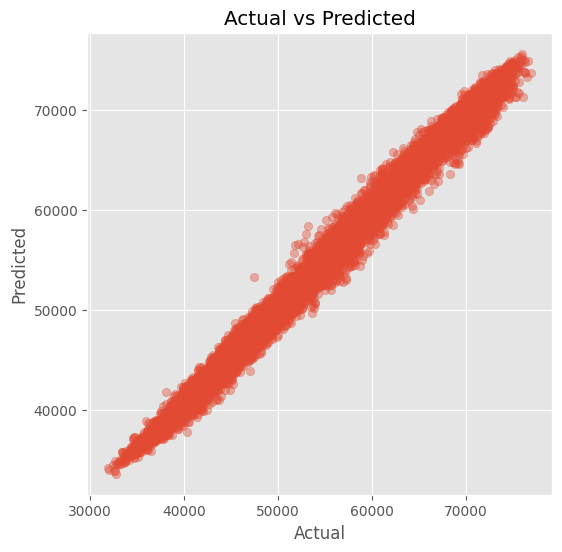

In [85]:
plt.figure(figsize=(6,6))

plt.scatter(

    actual,

    pred,

    alpha=0.4

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

Save Model

In [86]:
model.save("LSTM_Electricity_Model.keras")

print("Model Saved Successfully")

Model Saved Successfully


### Part 7: Final Evaluation

Combine Results from All Models

In [87]:
# Add benchmark results
benchmark_results = benchmark_results.copy()

# Combine all model results
all_results = pd.concat([
    benchmark_results,
    sarima_results,
    sarimax_results,
    rf_results,
    gbr_results,
    lstm_results
], ignore_index=True)

# Round values
all_results = all_results.round(4)

display(all_results)

,Model,MAE,RMSE,MAPE,R2
0,Mean,3788.8331,4397.2997,0.0697,-0.0121
1,Naive,3783.2029,4459.1085,0.0679,-0.0408
2,Seasonal Naive,2318.5206,3006.7608,0.0441,0.5268
3,Drift,4339.8907,5117.9573,0.0805,-0.3710
4,SARIMA,8077.8242,9434.2512,0.1519,-3.6588
5,SARIMAX,6738.3127,7825.2859,0.1268,-2.2052
6,Random Forest,1619.5067,2258.7907,0.0310,0.7329
7,Gradient Boosting,1600.5794,2200.8899,0.0306,0.7465
8,LSTM,761.6608,996.6045,0.0143,0.9900


Save Results Table




In [88]:
all_results.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Model comparison table saved successfully.")

Model comparison table saved successfully.


CELL 85 – RMSE Comparison

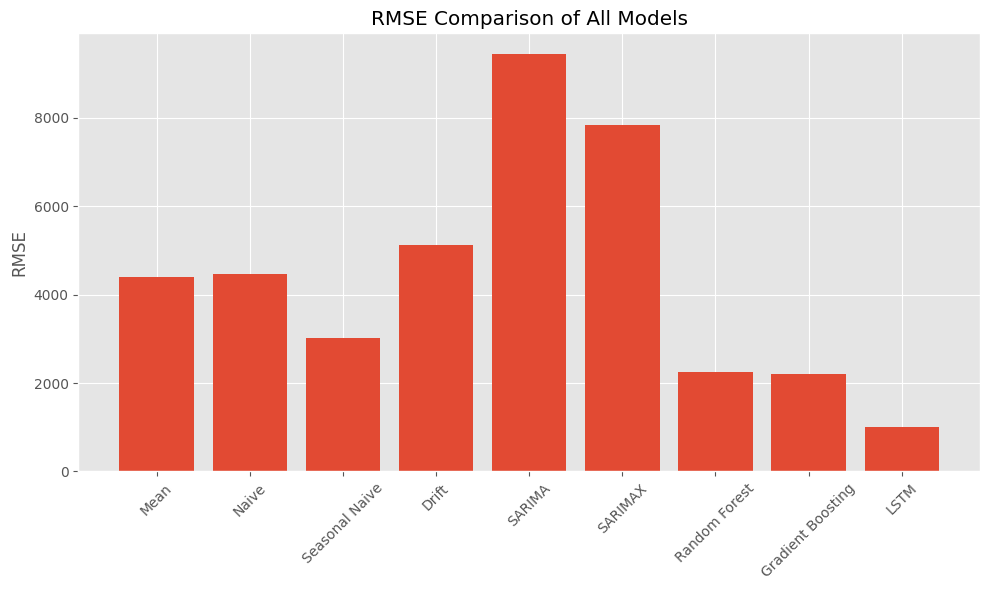

In [89]:
plt.figure(figsize=(10,6))

plt.bar(
    all_results["Model"],
    all_results["RMSE"]
)

plt.xticks(rotation=45)

plt.ylabel("RMSE")

plt.title("RMSE Comparison of All Models")

plt.tight_layout()

plt.show()

MAE Comparison

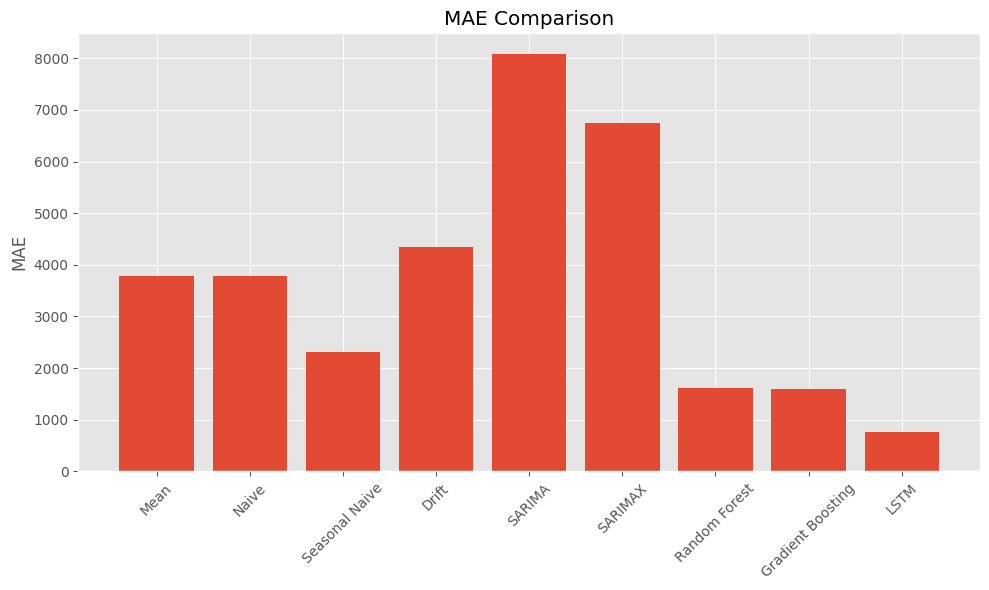

In [90]:
plt.figure(figsize=(10,6))

plt.bar(
    all_results["Model"],
    all_results["MAE"]
)

plt.xticks(rotation=45)

plt.ylabel("MAE")

plt.title("MAE Comparison")

plt.tight_layout()

plt.show()

MAPE Comparison

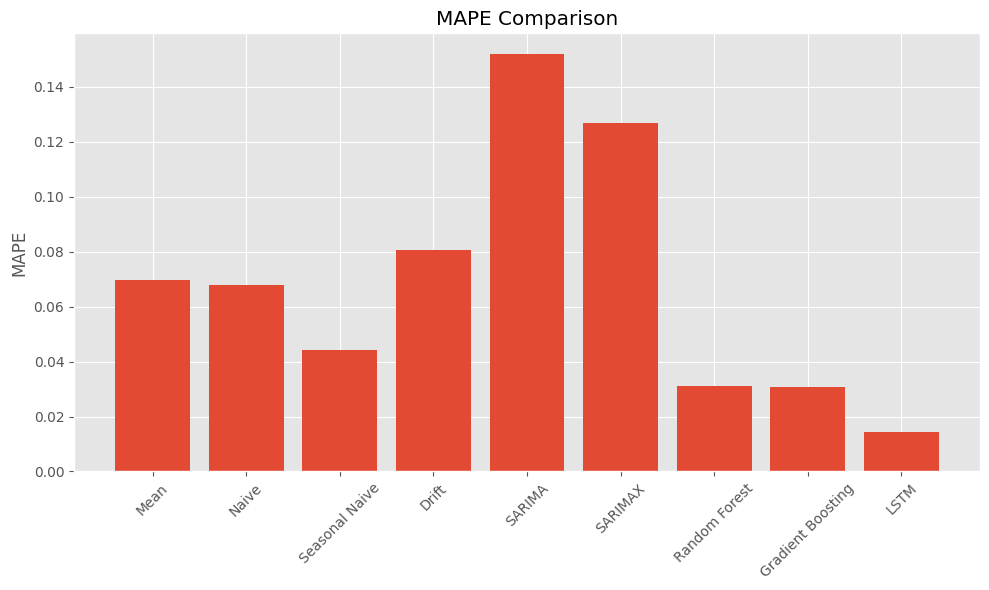

In [91]:
plt.figure(figsize=(10,6))

plt.bar(
    all_results["Model"],
    all_results["MAPE"]
)

plt.xticks(rotation=45)

plt.ylabel("MAPE")

plt.title("MAPE Comparison")

plt.tight_layout()

plt.show()

Best Model

In [92]:
best_model = all_results.loc[
    all_results["RMSE"].idxmin()
]

print("Best Performing Model")

display(best_model)

Best Performing Model


,8
Model,LSTM
MAE,761.6608
RMSE,996.6045
MAPE,0.0143
R2,0.99


Combined Forecast Comparison

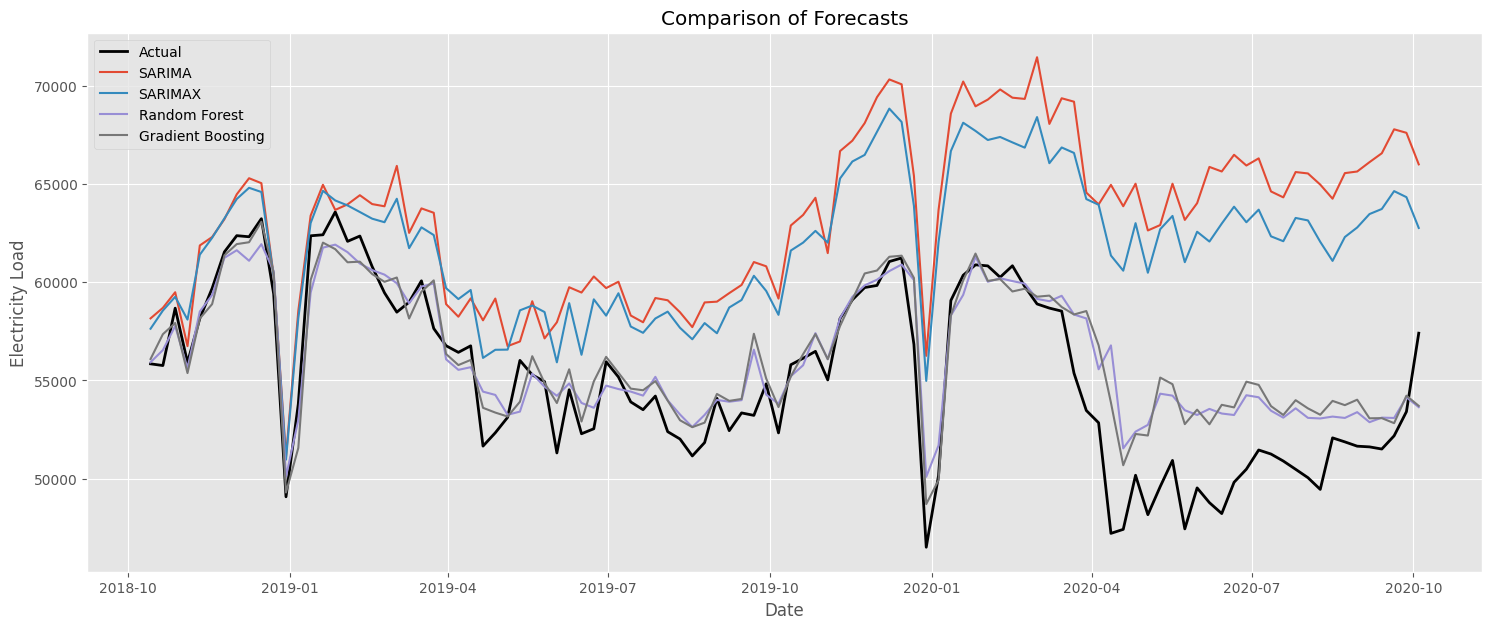

In [93]:
plt.figure(figsize=(18,7))

plt.plot(
    test.index,
    test["Load"],
    label="Actual",
    color="black",
    linewidth=2
)

plt.plot(
    test.index,
    forecast_mean,
    label="SARIMA"
)

plt.plot(
    test_exog.index,
    sarimax_forecast,
    label="SARIMAX"
)

plt.plot(
    test_ml.index,
    rf_pred,
    label="Random Forest"
)

plt.plot(
    test_ml.index,
    gbr_pred,
    label="Gradient Boosting"
)

plt.title("Comparison of Forecasts")

plt.xlabel("Date")

plt.ylabel("Electricity Load")

plt.legend()

plt.show()

Save All Outputs

In [94]:
plt.savefig("Forecast_Comparison.png", dpi=300)

print("Forecast plot saved.")

print("Notebook execution completed successfully.")

Forecast plot saved.
Notebook execution completed successfully.


<Figure size 640x480 with 0 Axes>